# Linear Regression
#####    Practical assignment 5

This practical assignment need to be handed in on Brightspace before the deadline, 15:30, 30/05/2023.  Make sure that every cell is executed/compiled and renamed to

**Assignment5_Surname1_Surname2.ipynb**

before submitting. For questions contact your TA during the workgroup, or via mail or Discord. Depending on whether all questions are sufficiently answered and if enough effort has been put into the assignment, you wil get good (all questions answered and all topics underestood well), sufficient (enough effort has been put but need to learn more and underestand better) or fail (not enough effort has been put into this assignment).

**Name 1:** Angelina Podolako - s1125886




**Name 2:** Feliks Lysiuk - s1125187

### Dataset

The movie [Moneyball](https://en.wikipedia.org/wiki/Moneyball_(film)) focuses on the "quest for the secret of success in baseball". It follows a low-budget team, the Oakland Athletics, who believed that underused statistics, such as a player's ability to get on base, better predict the ability to score runs than typical statistics like home runs, RBIs (runs batted in), and batting average. Obtaining players who excelled in these underused statistics turned out to be much more affordable for the team.

In this assignment we'll be looking at data from all 30 Major League Baseball teams from 2011 and examine their linear relationship between runs scored in a season and a number of other player statistics. Our aim will be to summarize these relationships both graphically and numerically in order to find which variable, if any, helps us best predict a team's runs scored in a season.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_style("whitegrid")

In [3]:
from google.colab import files
uploaded = files.upload()

Saving BaseballStats.csv to BaseballStats.csv


In [4]:
baseball = pd.read_csv('BaseballStats.csv')
print(baseball)

                     team  runs  at_bats  hits  homeruns  bat_avg  strikeouts  \
0           Texas Rangers   855     5659  1599       210    0.283         930   
1          Boston Red Sox   875     5710  1600       203    0.280        1108   
2          Detroit Tigers   787     5563  1540       169    0.277        1143   
3      Kansas City Royals   730     5672  1560       129    0.275        1006   
4     St. Louis Cardinals   762     5532  1513       162    0.273         978   
5           New York Mets   718     5600  1477       108    0.264        1085   
6        New York Yankees   867     5518  1452       222    0.263        1138   
7       Milwaukee Brewers   721     5447  1422       185    0.261        1083   
8        Colorado Rockies   735     5544  1429       163    0.258        1201   
9          Houston Astros   615     5598  1442        95    0.258        1164   
10      Baltimore Orioles   708     5585  1434       191    0.257        1120   
11    Los Angeles Dodgers   

Here are the descriptions of the variables in this dataset:

*  team: Team name
*  runs: Number of runs

*Traditional variables for predicting the number of runs*
*  at_bats: Number of at bats (the number of times a batter had a turn batting against a pitcher)
*  hits: Number of hits (when the batter safely reaches or passes first base after hitting the ball into fair territory)
*  homerun: Number of home runs.
*  bat_avg: Batting average (the number of hits divided by at bats)
*  strikeouts: Number of strikeouts (when a batter racks up three strikes during a time at bat).
*  stolen_bases: Number of stolen bases (when a runner advances to a base to which he is not entitled)
*  wins: Number of wins.

*New variables for predicting the number of runs*
*  new_onbase: On base percentage, measure of how often a batter reaches base for any reason other than a fielding error, fielder's choice, dropped/uncaught third strike, fielder's obstruction, or catcher's interference.
*  new_slug: Slugging percentage, measure of the power of a hitter calculated as the total bases divided by at bats.
*  new_obs: On base plus slugging, calculated as the sum of these two variables



We will start by looking at the association between the number of runs and the number of at bats.

### <span style="color:red"> Question 1 </span>
Looking at the data is an important first step in any analysis. Choose an appropriate plot to visualize the association between `runs` and `at_bats`  (with `runs` as $y$-value). Describe the relationship between these two variables. Make sure to discuss the form, direction, and strength of the relationship as well as any unusual observations. Would you be comfortable fitting a linear model to these data?

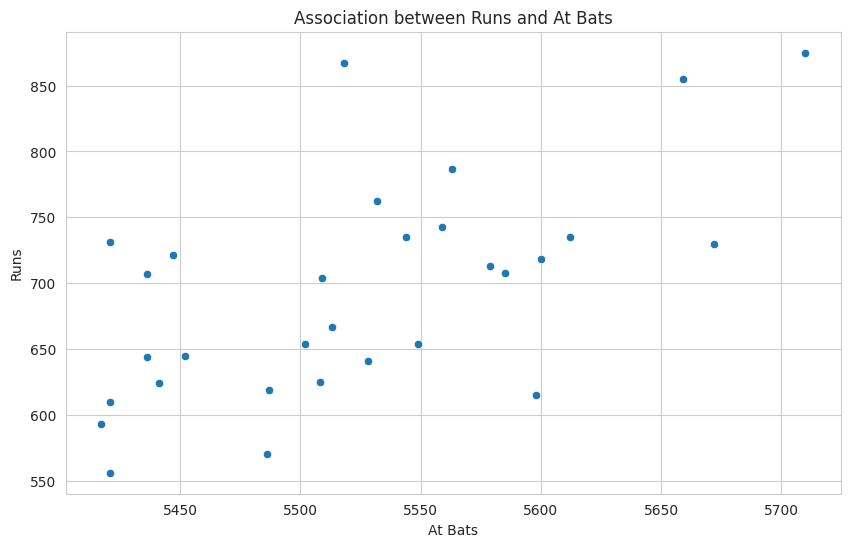

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='at_bats', y='runs', data=baseball)

# we can add regression line, but as I understood we do not nned due question 3
#sns.regplot(x='at_bats', y='runs', data=baseball, scatter=False, color='red')

plt.title('Association between Runs and At Bats')
plt.xlabel('At Bats')
plt.ylabel('Runs')

plt.grid(True)
plt.show()

Answer:
We can observe a weak linear relationship. It's weak because there are many outliers and residuals. It's not the most convenient linear plot, however, it's workable. Additionally, we can see that the plot is ascending.

If the relationship looks linear, we can quantify the strength of the relationship with the correlation coefficient.

In [6]:
baseball['runs'].corr(baseball['at_bats'])

0.6106270467206687

In order to determine the best fit line we can use 'statsmodels', a very useful module for the estimation of many different statistical models, as well as for conducting statistical tests, and statistical data exploration.

In [7]:
# the following means: explain variable 'runs' as a function of (some transformation of) variable 'at_bats'
formula_string = "runs ~ at_bats"

# remember OLS = "ordinary least squares" - by far the most commonly used form of linear regression
model = sm.formula.ols(formula = formula_string, data = baseball)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:                   runs   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     16.65
Date:                Mon, 27 May 2024   Prob (F-statistic):           0.000339
Time:                        08:47:55   Log-Likelihood:                -167.44
No. Observations:                  30   AIC:                             338.9
Df Residuals:                      28   BIC:                             341.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2789.2429    853.696     -3.267      0.0

### <span style="color:red"> Question 2 </span>

Based on the output above, write down the best-fit line, as well as the $R^{2}$ of the model.


Answer:
The best-fit line: y = (-2789.2429) + 0.6306 * x

*   Intercept = -2789.2429 => when x (at_bats) is zero, y (runs) is -2789.2429.
*   Coef for at_bats is 0.6305 => for eveachery increase in x (at_bats), y (runs) increases by 0.6305.


R^2 of the model: = 0.373 => approximately 37.3% of the output in the dependent variable y (runs) is explained by the independent variable x (at_bats).


### <span style="color:red"> Question 3 </span>

Plot the association between the two variables again, but this time with the linear model added so there is a visualisation of the model with the data.
First, plot the association between the variables, as you did above in Question 1. Second, use the formula you specified above to compute the predicted number of runs ($\hat{y}$) for each value of `at_bats` (${x}$). You can access the intercept and slope of the fitted model by indexing `model_fitted.params`. Finally, use a lineplot (`sns.lineplot`) to visualize the regression line on top of the first plot.

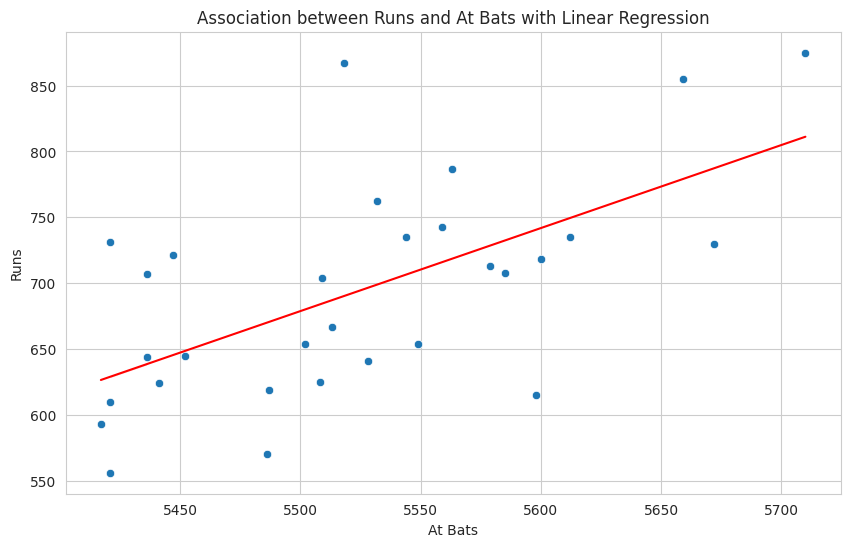

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='at_bats', y='runs', data=baseball)

intercept = model_fitted.params['Intercept']
slope = model_fitted.params['at_bats']

predicted_numb_runs = intercept + slope * baseball['at_bats']

sns.lineplot(x=baseball['at_bats'], y=predicted_numb_runs, color='red')

plt.title('Association between Runs and At Bats with Linear Regression')
plt.xlabel('At Bats')
plt.ylabel('Runs')

plt.grid(True)
plt.show()

### Model diagnostics

To assess whether the linear model is reliable, we need to check for (1) linearity, (2) nearly normal residuals, and (3) constant variability.

Linearity: You already checked if the relationship between runs and `at_bats` is linear using a scatterplot. We should also verify this condition with a plot of the residuals vs. `at_bats`.

### <span style="color:red"> Question 4 </span>

To check linearity, plot `at_bats` against the residual scores. Remember that the residual scores are defined by:

$$e_{i} = y_{i} - \hat{y}_{i}$$

where $e_{i}$ is the residual value, $y_{i}$ is the actual $y$-value, and $\hat{y}_{i}$ is the predicted $y$-value (Hint: use `sns.residplot` for the plotting part).

Does the data show a linear trend? Why do you think so?

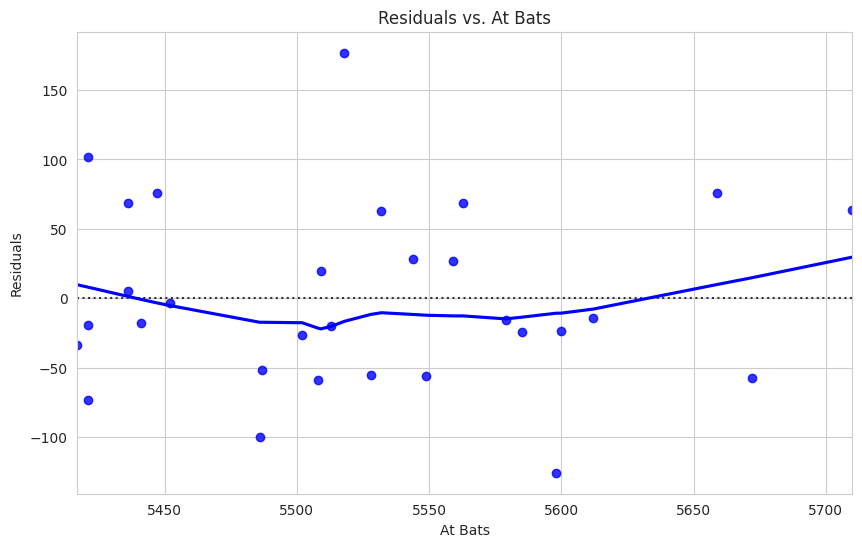

In [9]:
residuals = baseball['runs'] - predicted_numb_runs

plt.figure(figsize=(10, 6))
sns.residplot(x=baseball['at_bats'], y=residuals, lowess=True, color='blue')

plt.title('Residuals vs. At Bats')
plt.xlabel('At Bats')
plt.ylabel('Residuals')

plt.grid(True)
plt.show()



Answer:
I don't see a linear trend, as the graph first decreases, then increases. Which is more like a parabola.

### <span style="color:red"> Question 5 </span>

Now we will check whether the residuals are *normally distributed*.Plot the residual values in a histogram and a QQ-plot (use `probplot` from `scipy.stats` as `probplot(residual_values, plot=plt)`) to visualize whether these scores are normally distributed or not. Explain your thoughts.

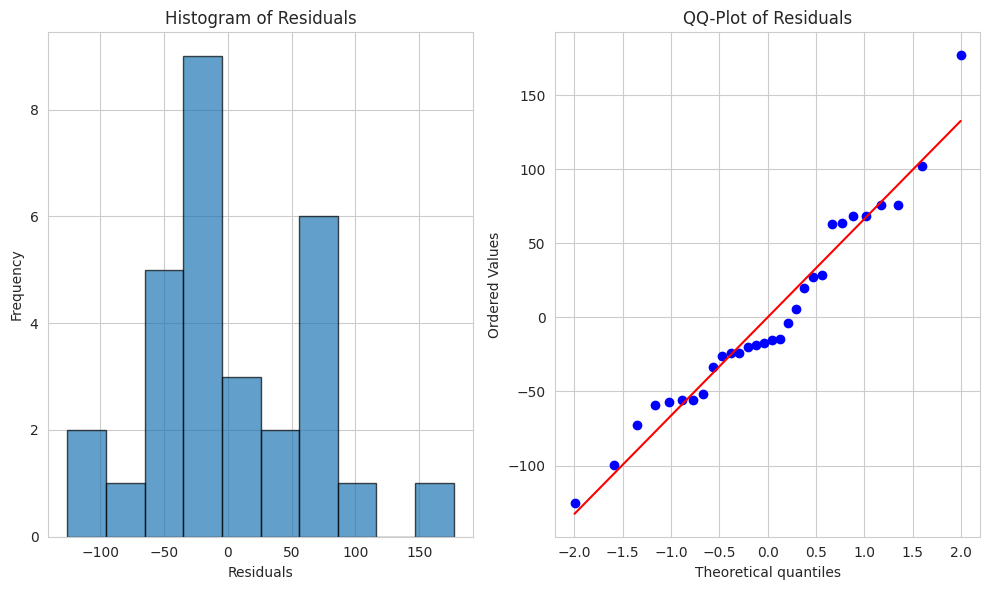

In [13]:
from scipy import stats

plt.figure(figsize=(10, 6))

#Histogram
plt.subplot(1, 2, 1)
plt.hist(residuals, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
#QQ-plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, plot=plt)
plt.title('QQ-Plot of Residuals')

plt.tight_layout()
plt.show()

Answer:
Histogram: If the residues are normally distributed, then the histogram should have a bell shape, that is, a symmetrical distribution. We have a graph that vaguely resembles the shape of a bell, since there are large outliers. Also, this (crooked) histogram has a left shift.

QQ graph: If the residuals are normally distributed, the points on the QQ graph will be located approximately in a straight line. In our case, the remnants were distributed as if wrapping around the line. They are also approximately in a straight line, but still have a stepped appearance.

Based on the histogram and the QQ graph, it can be concluded that the residuals do not strongly correspond to the normal distribution

### <span style="color:red"> Question 6 </span>

Constant variability is the last condition that we will check. This means that we look at the plot of <span style="color:red">Question 4</span> and determine (qualitatively, by "eye-balling" the plot) if the variability is rougly equal along the whole range of the x-axis.
Determine whether the data has a constant variability (with respect to the model). Why do you think so?

**Answer**: I think that variability is not even roughly equal along x-axis, as more we go to the right, the less points we have.

Great! You now have succesfully created a linear model on the data, and analyzed it's validity. There are many more regression techniques for different type of data, but for the next question we will stick with the linear ones.

### <span style="color:red"> Question 7 </span>

 - Create a linear model for one other traditional variables vs runs (hits, homeruns, bat_avg, strikeouts, stolen_bases, or wins). Choose one you think will be a good predictor. Write down the linear formula and the $R^{2}$. Don't forget to create a plot to visualize the association between the two variables.

 - Create a linear model for one of the 3 new variables (new_onbase, new_slug, new_obs) and write down the linear formula and the $R^{2}$ and create a plot to visualize the association between the two variables.

 - From the two variables you have chosen above, which variable predicts the `runs` variable the best? Why?

- Check the model diagnostics for the regression model with the variable you decided was the best predictor for runs. Do these model diagnostics indicate that this linear model is reliable?

bat_avg vs runs
Linear Formula: Runs = -642.82 + 5242.23 * bat_avg
R-squared value: 0.66
new_onbase vs runs
Linear Formula: Runs = -1118.42 + 5654.32 * new_onbase
R-squared value: 0.85


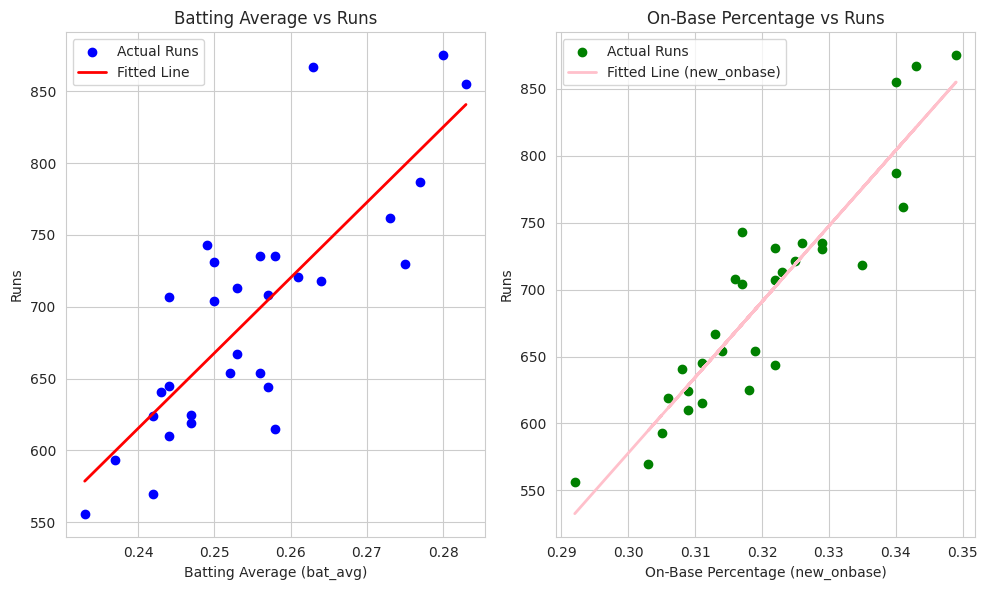

In [22]:
#  Beta_avg vs runs
model = sm.OLS(baseball['runs'], sm.add_constant(baseball['bat_avg'])).fit()

beta_0 = model.params['const']
beta_1 = model.params['bat_avg']

r_squared = model.rsquared

y_predict = model.predict(sm.add_constant(baseball['bat_avg'])) #predict the number of runs based on the average bat_avg

print("bat_avg vs runs")
print(f"Linear Formula: Runs = {beta_0:.2f} + {beta_1:.2f} * bat_avg")
print(f"R-squared value: {r_squared:.2f}")

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.scatter(baseball['bat_avg'], baseball['runs'], color='blue', label='Actual Runs')
plt.plot(baseball['bat_avg'], y_predict, color='red', linewidth=2, label='Fitted Line')
plt.xlabel('Batting Average (bat_avg)')
plt.ylabel('Runs')
plt.title('Batting Average vs Runs')
plt.legend()

#  new_onbase vs runs
model_new_onbase = sm.OLS(baseball['runs'], sm.add_constant(baseball['new_onbase'])).fit()

beta_0_new_onbase = model_new_onbase.params['const']
beta_1_new_onbase = model_new_onbase.params['new_onbase']

r_squared_new_onbase = model_new_onbase.rsquared

y_predict_new_onbase = model_new_onbase.predict(sm.add_constant(baseball['new_onbase']))

print("new_onbase vs runs")
print(f"Linear Formula: Runs = {beta_0_new_onbase:.2f} + {beta_1_new_onbase:.2f} * new_onbase")
print(f"R-squared value: {r_squared_new_onbase:.2f}")

plt.subplot(1, 2, 2)
plt.scatter(baseball['new_onbase'], baseball['runs'], color='green', label='Actual Runs')
plt.plot(baseball['new_onbase'], y_predict_new_onbase, color='pink', linewidth=2, label='Fitted Line (new_onbase)')
plt.xlabel('On-Base Percentage (new_onbase)')
plt.ylabel('Runs')
plt.title('On-Base Percentage vs Runs')
plt.legend()

plt.tight_layout()
plt.show()

**bat_avg vs runs**
Linear Formula: Runs = -642.82 + 5242.23 * bat_avg
R-squared value: 0.66
The graph is in the values from 0.23 to 0.285 on the x and from 550 to 900 on the y axis. The points are very scattered from the line, but there are also those points that are on the straightest line. You can see that the points form a medium-strength linearity, positive, with discards.


**new_onbase vs runs**
Linear Formula: Runs = -1118.42 + 5654.32 * new_onbase
R-squared value: 0.85
The graph is in the values from 0.29 to 0.35 on the x and from 550 to 900 on the y axis. The points are much less scattered from the line, many points are on the straightest line. You can see that the points form a strong linearity, positive, I do not observe any discards.




Of the two variables: bat_avg and new_on base, new_on base predicts the number of runs better. This is due to the higher value of the coefficient of determination (R-squared) = 0.85, compared with the R-squared bat_avg = 0.66. This means that the model using new_onbase as a predictor better explains the variability of the number of runs than the model with bat_avg.

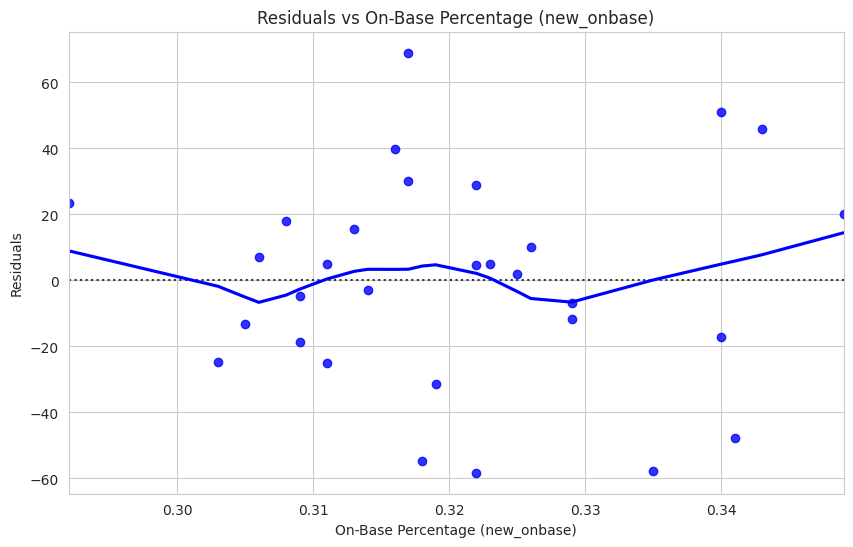

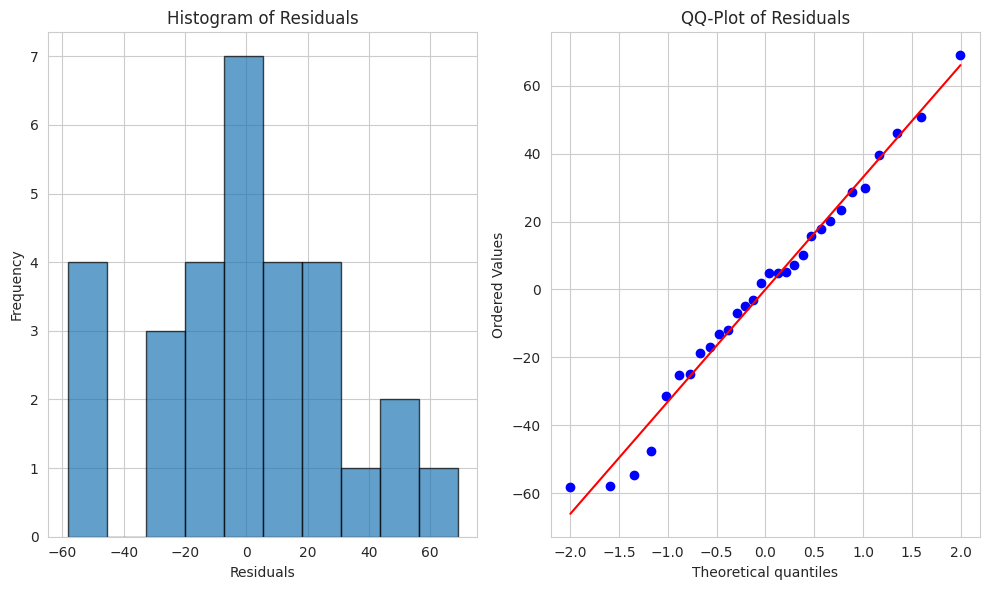

In [26]:
residuals_new_onbase = baseball['runs'] - y_predict_new_onbase

# residuals vs new_onbase
plt.figure(figsize=(10, 6))
sns.residplot(x=baseball['new_onbase'], y=residuals_new_onbase, lowess=True, color='blue')

plt.title('Residuals vs On-Base Percentage (new_onbase)')
plt.xlabel('On-Base Percentage (new_onbase)')
plt.ylabel('Residuals')

plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

# histogram
plt.subplot(1, 2, 1)
plt.hist(residuals_new_onbase, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# QQ-plot
plt.subplot(1, 2, 2)
stats.probplot(residuals_new_onbase, plot=plt)
plt.title('QQ-Plot of Residuals')

plt.tight_layout()
plt.show()

The residuals appear to be approximately normal, clustering around the straight line and wrapping it. The plot exhibits a distinct dome shape, with points aligning along the line. This indicates a linear relationship. We also observe a strong association between the base percentage and runs.